# Enphase Envoy Solar Production Analysis

This project analyzes solar energy production data pulled from my Enphase Envoy Home Assistant database (`enphase_envoy_400d.db`), covering **August 2025 through July 2026** — roughly a year of production statistics.

The goal of this project is to create visualizations to help us better understand solar production trends in everyday homes in the United States. The following questions were examined:

| Chart | Question it answers |
|---|---|
| Monthly peak day | What was the *best single day* each month? |
| Monthly average (full day) | What's a *typical day's total output* each month? |
| Monthly average (11am–1pm window) | How intense is *peak-sun production* each month, independent of day length? |

All three pull from the same underlying sensor: `sensor.envoy_202333046988_lifetime_energy_production` — a cumulative, ever-increasing energy counter recorded once per hour. Because it never resets, any two readings can simply be subtracted to get the energy produced between them. 

In [1]:
import sqlite3
import statistics
from datetime import date

import matplotlib.pyplot as plt

import envoy_data as ed

%matplotlib inline

START_MONTH = date(2025, 8, 1)
END_MONTH = date(2026, 7, 1)  # inclusive

conn = sqlite3.connect(ed.DB_PATH)
metadata_id = ed.fetch_metadata_id(conn, ed.ENTITY_ID)
months = ed.month_range(START_MONTH, END_MONTH)
print(f"Tracking {ed.ENTITY_ID} (metadata_id={metadata_id}) across {len(months)} months")

Tracking sensor.envoy_202333046988_lifetime_energy_production (metadata_id=7) across 12 months


## Shared Plotting

For simplicity, all three charts use the same visual language — a simple line-graph with dot markers, direct labels only on the overall max/min points (not every point), and a light, low-contrast grid. Defining it once keeps the three charts visually consistent and avoids repeating the same ~40 lines of matplotlib setup three times.

In [2]:
# Reference palette (dataviz skill defaults, light mode)
COLOR_LINE = "#2a78d6"
COLOR_INK_PRIMARY = "#0b0b0b"
COLOR_INK_SECONDARY = "#52514e"
COLOR_INK_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_BASELINE = "#c3c2b7"
COLOR_SURFACE = "#fcfcfb"


def plot_monthly_line(months, values, title, ylabel, value_fmt="{:.1f} kWh"):
    labels = [m.strftime("%b\n%Y") for m in months]
    valid_x = [i for i, v in enumerate(values) if v is not None]
    valid_y = [values[i] for i in valid_x]

    fig, ax = plt.subplots(figsize=(11, 6), facecolor=COLOR_SURFACE)
    ax.set_facecolor(COLOR_SURFACE)

    ax.plot(
        valid_x, valid_y,
        color=COLOR_LINE, linewidth=2, marker="o", markersize=8,
        markerfacecolor=COLOR_LINE, markeredgecolor=COLOR_SURFACE,
        markeredgewidth=1.5, solid_capstyle="round", zorder=3,
    )

    # Direct-label only the overall max and min — not every point.
    if valid_y:
        max_i = valid_x[valid_y.index(max(valid_y))]
        min_i = valid_x[valid_y.index(min(valid_y))]
        for i in {max_i, min_i}:
            ax.annotate(
                value_fmt.format(values[i]),
                (i, values[i]), textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=9, color=COLOR_INK_SECONDARY,
            )

    ax.set_xticks(range(len(months)))
    ax.set_xticklabels(labels, color=COLOR_INK_MUTED, fontsize=9)
    ax.set_ylabel(ylabel, color=COLOR_INK_SECONDARY, fontsize=10)
    ax.set_title(title, color=COLOR_INK_PRIMARY, fontsize=14, fontweight="bold", pad=16)

    ax.grid(axis="y", color=COLOR_GRID, linewidth=1, zorder=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(COLOR_BASELINE)
    ax.tick_params(axis="y", colors=COLOR_INK_MUTED, labelsize=9)
    ax.tick_params(axis="x", length=0)

    fig.tight_layout()
    plt.show()
    return fig

## 1. Monthly Peak Production

**How the curve is calculated:**
1. For every day in range, we take the cumulative-energy reading recorded at the close of that day and subtract the previous day's closing reading. That difference is the day's total production (in kWh).
2. Within each calendar month, keep only the single **highest** daily value — every other day in that month is discarded.

So this line is **not** a monthly total or a monthly average — it's *the best single day the panels had* each month, i.e. the system's demonstrated ceiling.

Month     | Peak day   | Peak production
---------------------------------------------
Aug 2025  | 2025-08-31 | 61.40 kWh
Sep 2025  | 2025-09-01 | 58.57 kWh
Oct 2025  | 2025-10-09 | 56.36 kWh
Nov 2025  | 2025-11-17 | 46.78 kWh
Dec 2025  | 2025-12-04 | 47.02 kWh
Jan 2026  | 2026-01-20 | 51.69 kWh
Feb 2026  | 2026-02-19 | 59.61 kWh
Mar 2026  | 2026-03-28 | 68.51 kWh
Apr 2026  | 2026-04-20 | 71.06 kWh
May 2026  | 2026-05-30 | 68.81 kWh
Jun 2026  | 2026-06-20 | 65.39 kWh
Jul 2026  | 2026-07-23 | 66.81 kWh


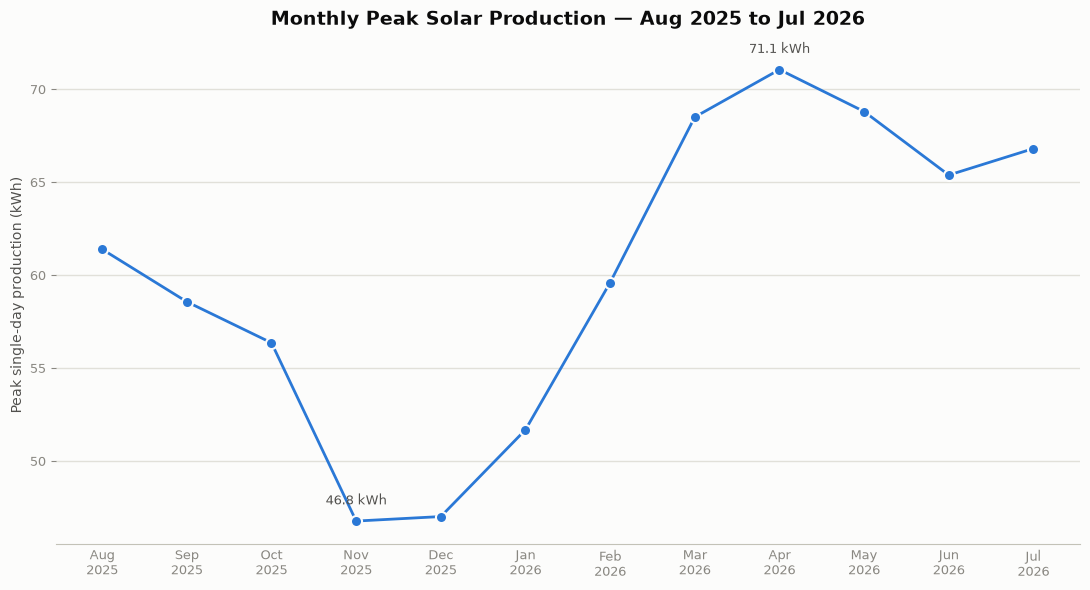

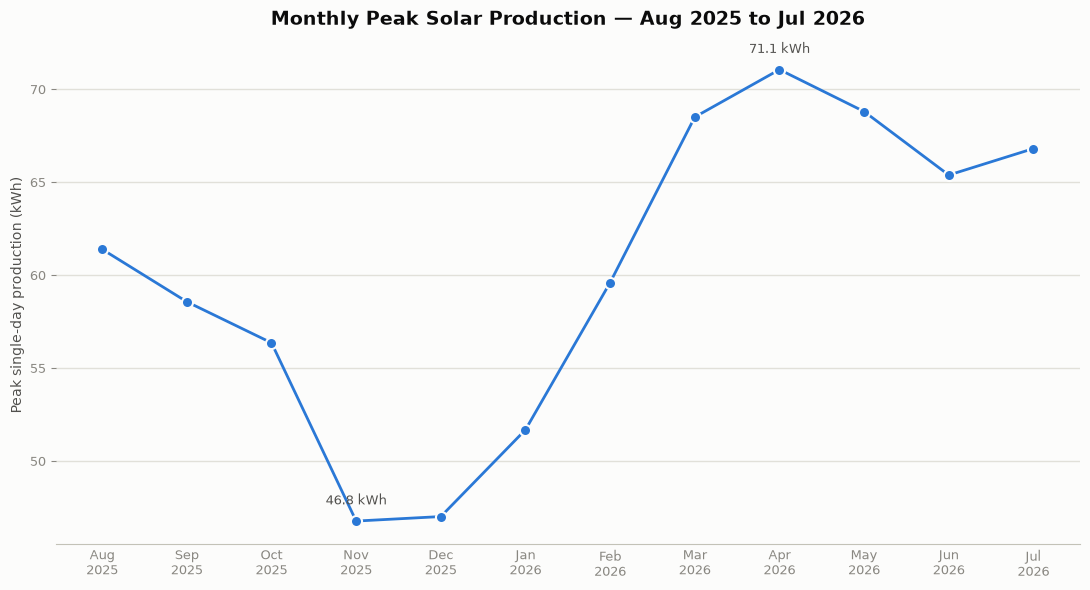

In [3]:
daily_kwh = ed.fetch_daily_kwh(conn, metadata_id, START_MONTH, END_MONTH)
month_groups = ed.group_by_month(daily_kwh, START_MONTH, END_MONTH)

peaks = {}
for month_start, days in month_groups.items():
    peaks[month_start] = max(days, key=days.get) if days else None

peak_values = [days[peaks[m]] if peaks[m] else None for m, days in zip(months, month_groups.values())]

print("Month     | Peak day   | Peak production")
print("-" * 45)
for m, v in zip(months, peak_values):
    day = peaks[m]
    print(f"{m.strftime('%b %Y')}  | {day.strftime('%Y-%m-%d') if day else '  no data'} | {f'{v:.2f} kWh' if v else '-'}")

plot_monthly_line(
    months, peak_values,
    title="Monthly Peak Solar Production — Aug 2025 to Jul 2026",
    ylabel="Peak single-day production (kWh)",
)

### Insights

- **Peak-day production can overcome seasonal adversity**. If you look at the monthly average solar production chart below, you would see that November, December and January contain the lowest averages. However, despite their averages being the lowest, their daily peaks for each month greatly exceed their average numbers:

    - Nov Peak = 46.78 kWh (-) Nov Monthly Average = 20.23 kWh => Difference  | **26.55 kWh** |
     - Dec Peak = 47.02 kWh (-) Dec Monthly Average = 16.45 kWh => Difference | **30.57 kWh** |
     - Jan Peak = 51.69 kWh (-) Jan Monthly Average = 19.54 kWh => Difference | **32.15 kWh** |

 
According to the data, November, December and January peaked **131.2%**, **185.8%** and **164.5%** above their monthly averages respectively. This suggests that colder months contain much more variability in their numbers, making them more unreliable for solar production. However, if favorable conditions present themselves, peak production can get close to mirroring the average production numbers of the strongest months. In future studies, it would be incredibly facsinating to examine what exact factors led to the Nov, Dec and Jan peaks observed in this dataset. 
- **The single best day of the whole year was April 20th, not June or July**, despite the sun sitting highest in the sky around the summer solstice. This is consistent with a well-known solar panel behavior: panel efficiency drops as panel temperature rises, so a clear, cool spring day with strong sun angle can out-produce a hotter mid-summer day. May and June's peaks (68.8 and 65.4 kWh) show the same pattern — all sit slightly below April's.
- **Nov and Dec are essentially tied** (46.8 vs 47.0 kWh) at the bottom — the shortest-day trough is broad, not a sharp dip around a single month.

## 2. Monthly Average Production (Full Day)

**How the curve is calculated:** same day-by-day differencing as above (closing reading minus previous day's closing reading), but this time **every** valid day in the month is kept, and the monthly point is the **mean** of all of them — not just the best one. This is the number that answers "what does a typical day look like this month."

Month     | Days used | Avg daily production
-----------------------------------------------
Aug 2025  |        31 | 49.19 kWh
Sep 2025  |        30 | 47.52 kWh
Oct 2025  |        31 | 39.42 kWh
Nov 2025  |        30 | 20.23 kWh
Dec 2025  |        31 | 16.45 kWh
Jan 2026  |        31 | 19.54 kWh
Feb 2026  |        28 | 29.41 kWh
Mar 2026  |        31 | 33.68 kWh
Apr 2026  |        30 | 39.87 kWh
May 2026  |        31 | 49.00 kWh
Jun 2026  |        30 | 50.84 kWh
Jul 2026  |        31 | 50.89 kWh


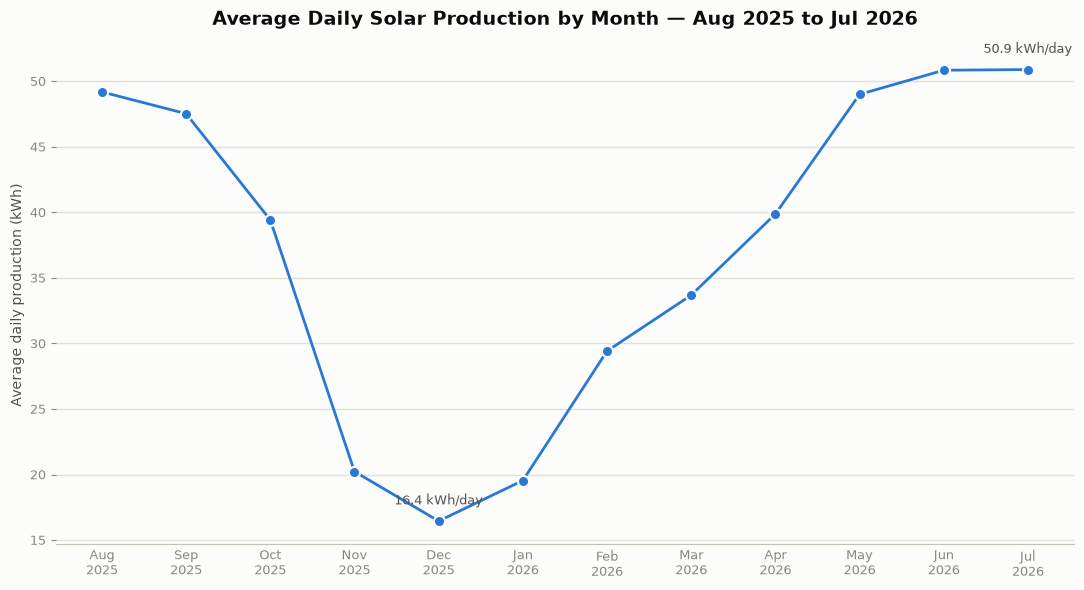

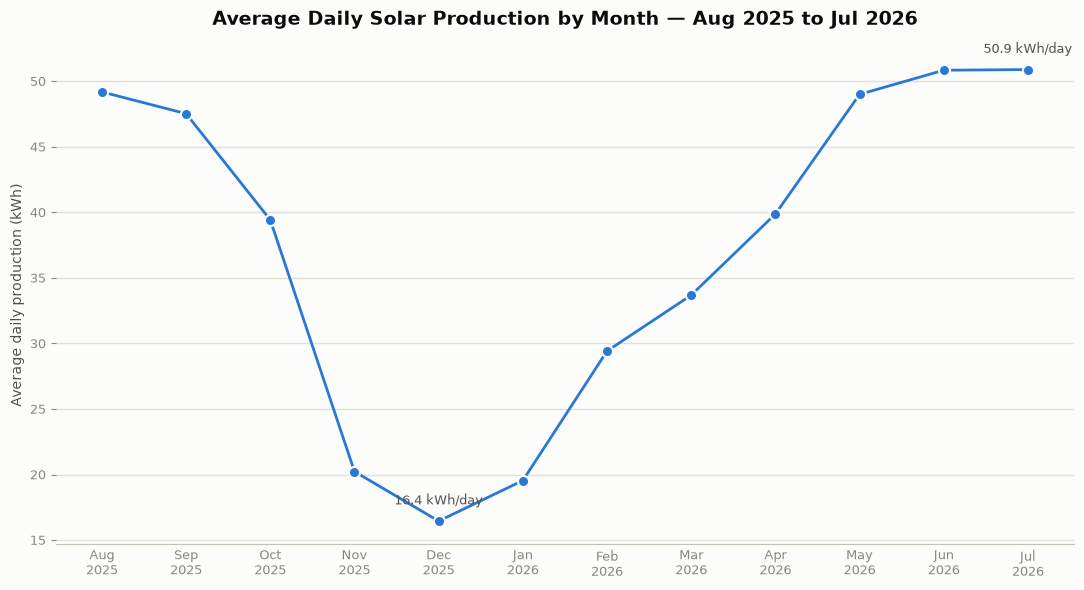

In [4]:
full_day_avg = {}
for month_start, days in month_groups.items():
    full_day_avg[month_start] = statistics.mean(days.values()) if days else None

full_day_values = [full_day_avg[m] for m in months]

print("Month     | Days used | Avg daily production")
print("-" * 47)
for m in months:
    n_days = len(month_groups[m])
    v = full_day_avg[m]
    print(f"{m.strftime('%b %Y')}  | {n_days:>9} | {f'{v:.2f} kWh' if v else '-'}")

plot_monthly_line(
    months, full_day_values,
    title="Average Daily Solar Production by Month — Aug 2025 to Jul 2026",
    ylabel="Average daily production (kWh)",
    value_fmt="{:.1f} kWh/day",
)

### Insights

- **This chart contains a much wider trough than the peak-day chart:** ~50.9 kWh/day average in Jul down to ~16.5 kWh/day in Dec, a **~3.1x range**, versus the peak chart's ~1.5x. Averaging is what exposes the real seasonal effect, as a collection of really poor production days in the colder seasons brings their averages way down.
- **The curve traces a roughly sinusoidal seasonal cycle**, bottoming near the winter solstice (Dec) and cresting near the summer solstice (Jun/Jul), which is exactly the shape you'd expect from day-length-driven solar irradiation.
- **December is the weakest month by every metric** (lowest peak, lowest full-day average, lowest midday average below).

## 3. Monthly Average Production, Midday Window (11am-1pm)

**How the curve is calculated:** Home Assistant's hourly statistics store, for each hour-long bucket, the cumulative sensor reading as of the *end* of that hour. So the bucket starting at 10:00 approximates the cumulative value **at 11:00**, and the bucket starting at 12:00 approximates the cumulative value **at 13:00**. Subtracting those two readings gives the energy produced in exactly that 2-hour window, for any day — no matter how long or short that day's sunrise-to-sunset stretch was.

Averaging that fixed 2-hour value across every day in a month puts every month on the **same clock-time footing**, which is the point: it removes day-length as a variable so what's left in the seasonal swing has to come from something else (sun angle, weather, atmosphere).

Window: 11:00-13:00 local time each day
Month     | Days used | Avg production in window
-----------------------------------------------
Aug 2025  |        31 | 11.04 kWh
Sep 2025  |        30 | 11.98 kWh
Oct 2025  |        31 | 10.95 kWh
Nov 2025  |        30 | 6.52 kWh
Dec 2025  |        31 | 5.54 kWh
Jan 2026  |        31 | 5.90 kWh
Feb 2026  |        28 | 7.93 kWh
Mar 2026  |        31 | 9.31 kWh
Apr 2026  |        30 | 9.22 kWh
May 2026  |        31 | 12.03 kWh
Jun 2026  |        30 | 12.01 kWh
Jul 2026  |        31 | 11.84 kWh


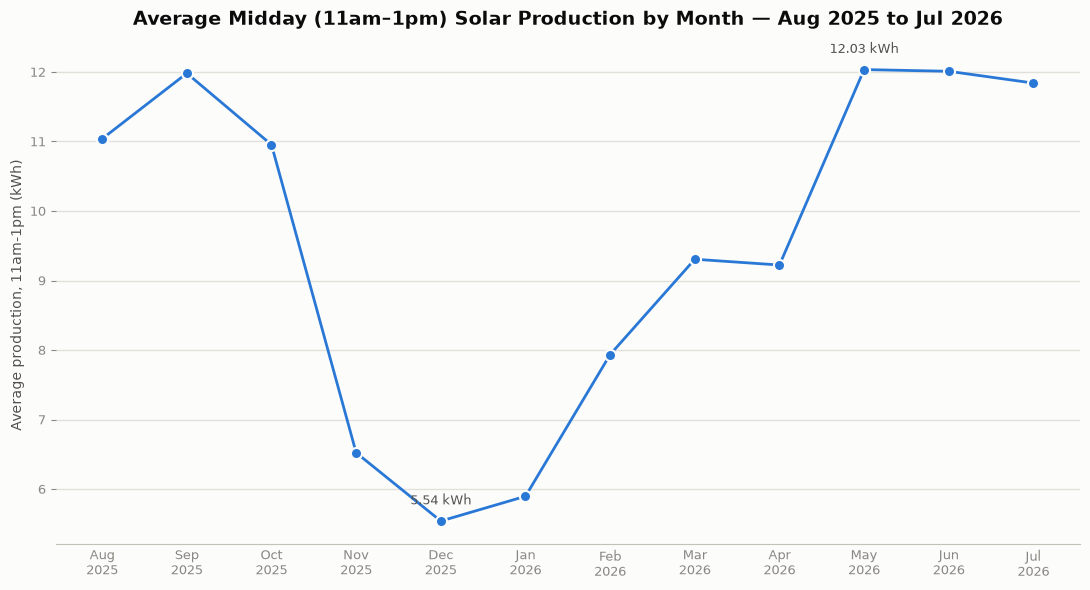

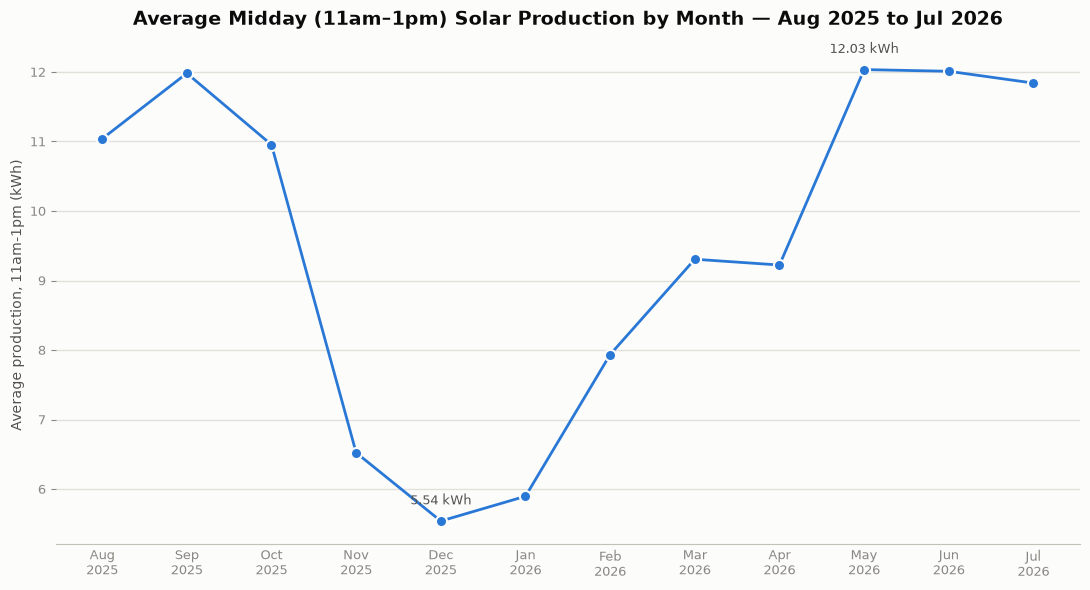

In [5]:
WINDOW_START_HOUR = 11
WINDOW_END_HOUR = 13

window_kwh = ed.fetch_window_kwh(
    conn, metadata_id, START_MONTH, END_MONTH, WINDOW_START_HOUR, WINDOW_END_HOUR
)
window_groups = ed.group_by_month(window_kwh, START_MONTH, END_MONTH)

midday_avg = {}
for month_start, days in window_groups.items():
    midday_avg[month_start] = statistics.mean(days.values()) if days else None

midday_values = [midday_avg[m] for m in months]

print(f"Window: {WINDOW_START_HOUR}:00-{WINDOW_END_HOUR}:00 local time each day")
print("Month     | Days used | Avg production in window")
print("-" * 47)
for m in months:
    n_days = len(window_groups[m])
    v = midday_avg[m]
    print(f"{m.strftime('%b %Y')}  | {n_days:>9} | {f'{v:.2f} kWh' if v else '-'}")

plot_monthly_line(
    months, midday_values,
    title="Average Midday (11am–1pm) Solar Production by Month — Aug 2025 to Jul 2026",
    ylabel="Average production, 11am-1pm (kWh)",
    value_fmt="{:.2f} kWh",
)

### Insights

- **The range compresses further once day-length is controlled for**: ~12.0 kWh in May down to ~5.5 kWh in Dec, a **~2.2x spread** — smaller than the full-day average's ~3.1x, but still noticeably larger than the peak-day chart's ~1.5x.
- That leftover ~2.2x swing, with day length now factored out, has to come from something else at solar noon itself: **lower winter sun angle** (more atmosphere for light to pass through, and a shallower angle of incidence on the panels) plus **more frequent winter cloud cover**. Day length explains part of the full-day story, but not all of it — midday intensity itself is meaningfully weaker in winter too.
- **The shape still tracks the same solstice-anchored curve** as the full-day average (trough in Dec, peak in late spring/early summer), just compressed — confirming this is a genuine seasonal irradiance effect and not an artifact of shorter winter days alone.

## Putting the three views together

Each chart answers a different question, and the gap between their max/min ratios is itself informative: it separates how much of winter's shortfall is *day length*, how much is *midday sun weakness*, and how much is *pure bad-day variance*.

In [6]:
def ratio(values):
    clean = [v for v in values if v is not None]
    return max(clean) / min(clean)

print(f"{'Metric':<30} | {'Min':>8} | {'Max':>8} | {'Max/Min ratio':>14}")
print("-" * 68)
for label, values in [
    ("Peak single day", peak_values),
    ("Full-day average", full_day_values),
    ("Midday (11am-1pm) average", midday_values),
]:
    clean = [v for v in values if v is not None]
    print(f"{label:<30} | {min(clean):>8.2f} | {max(clean):>8.2f} | {ratio(values):>13.2f}x")

Metric                         |      Min |      Max |  Max/Min ratio
--------------------------------------------------------------------
Peak single day                |    46.78 |    71.06 |          1.52x
Full-day average               |    16.45 |    50.89 |          3.09x
Midday (11am-1pm) average      |     5.54 |    12.03 |          2.17x


### Overall takeaways for the research project

- **Winter's energy shortfall is mostly about day length and weather consistency, not the sun itself "weakening".** The peak-day ratio (~1.5x) is the smallest of the three — on a good winter day, the panels can still perform close to a good summer day.
- **The full-day average ratio (~3.1x) is the largest**, and the midday-only ratio (~2.2x) sits in between. The jump from ~1.5x (peak) to ~2.2x (midday average) shows that *typical* winter days underperform even at solar noon — not just because of fewer daylight hours, but because winter sun itself is weaker and cloudier. The further jump from ~2.2x (midday) to ~3.1x (full day) is the added effect of shorter winter days stacking on top of that.
- **Spring, not summer, produced the single best day of the year** (Apr 20), a signature of panel temperature derating — worth keeping in mind for future research.
- **December is the consistent low point across all three metrics** — the month to plan around for any battery-sizing, backup-power, or worst-case-scenario analysis.

In [7]:
conn.close()